# Statistical Business Analysis
## Week 7 Data Science Internship Project

**Objective:** To perform a complete statistical analysis on the provided telecom customer churn dataset and sales data. This analysis covers descriptive statistics, distributions, correlation, hypothesis testing, confidence intervals, and regression modeling.


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Data Loading
Loading the `customer_churn.csv` and `sales_data.csv` datasets from the current directory.

In [2]:
# Load the datasets
churn_df = pd.read_csv('customer_churn.csv')
sales_df = pd.read_csv('sales_data.csv')

print("Customer Churn Data Shape:", churn_df.shape)
print("Sales Data Shape:", sales_df.shape)


Customer Churn Data Shape: (500, 9)
Sales Data Shape: (100, 7)


## 3. Data Exploration
Let's take a quick look at the first few rows and the data types of each dataset.

In [3]:
display(churn_df.head())
display(churn_df.info())


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


None

In [4]:
display(sales_df.head())
display(sales_df.info())


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


None

## 4. Descriptive Statistics
Calculating Mean, Median, Mode, Standard Deviation, Variance, Minimum, Maximum, Quartiles, and Interquartile Range (IQR) for relevant numerical columns.


In [5]:
def calculate_descriptive_stats(df, col_name):
    col = df[col_name].dropna()
    stats_dict = {
        'Mean': col.mean(),
        'Median': col.median(),
        'Mode': col.mode().iloc[0] if not col.mode().empty else np.nan,
        'Standard Deviation': col.std(),
        'Variance': col.var(),
        'Minimum': col.min(),
        'Maximum': col.max(),
        'Q1 (25%)': col.quantile(0.25),
        'Q3 (75%)': col.quantile(0.75),
        'IQR': col.quantile(0.75) - col.quantile(0.25)
    }
    return pd.Series(stats_dict)

print("--- Descriptive Statistics for Customer Churn: MonthlyCharges ---")
display(pd.DataFrame(calculate_descriptive_stats(churn_df, 'MonthlyCharges'), columns=['MonthlyCharges']))

print("\n--- Descriptive Statistics for Sales Data: Total_Sales ---")
display(pd.DataFrame(calculate_descriptive_stats(sales_df, 'Total_Sales'), columns=['Total_Sales']))

print("\n--- General Descriptive Statistics for all numerical columns ---")
display(churn_df.describe())
display(sales_df.describe())


--- Descriptive Statistics for Customer Churn: MonthlyCharges ---


,MonthlyCharges
Mean,113.636000
Median,115.000000
Mode,115.000000
Standard Deviation,51.799903
Variance,2683.229964
Minimum,20.000000
Maximum,199.000000
Q1 (25%),67.000000
Q3 (75%),158.000000
IQR,91.000000



--- Descriptive Statistics for Sales Data: Total_Sales ---


,Total_Sales
Mean,1.236505e+05
Median,9.795550e+04
Mode,6.540000e+03
Standard Deviation,1.001611e+05
Variance,1.003224e+10
Minimum,6.540000e+03
Maximum,3.739320e+05
Q1 (25%),3.951750e+04
Q3 (75%),1.757925e+05
IQR,1.362750e+05



--- General Descriptive Statistics for all numerical columns ---


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


## 5. Distribution Analysis
Creating Histograms, KDE plots, and Box plots. Performing Shapiro-Wilk Test for normality.


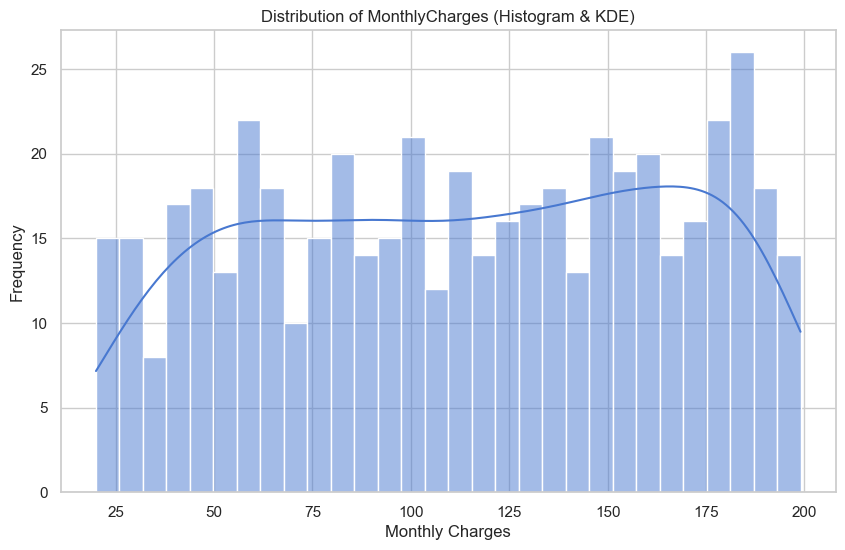

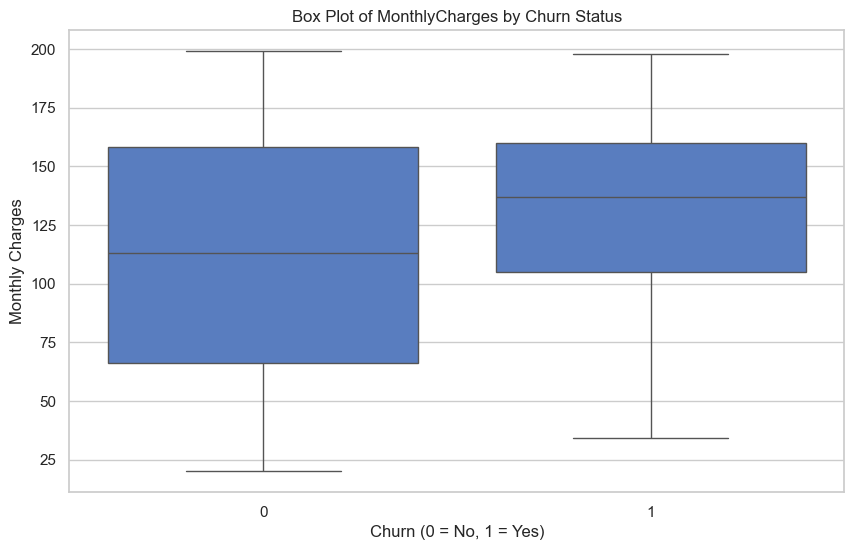

Shapiro-Wilk Test for MonthlyCharges -> Stat: 0.9520, p-value: 1.149e-11
Interpretation: Reject the null hypothesis. The MonthlyCharges distribution is not perfectly normal.


In [6]:
import os
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

# Histogram & KDE Plot
plt.figure()
sns.histplot(churn_df['MonthlyCharges'], kde=True, bins=30)
plt.title('Distribution of MonthlyCharges (Histogram & KDE)')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.savefig('visualizations/histogram.png')
plt.savefig('visualizations/kde_plot.png')
plt.show()

# Box Plot
plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_df)
plt.title('Box Plot of MonthlyCharges by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.savefig('visualizations/boxplot.png')
plt.show()

# Normality testing: Shapiro-Wilk Test
# H0: Data is normally distributed
stat, p_value = stats.shapiro(churn_df['MonthlyCharges'].dropna())
print(f"Shapiro-Wilk Test for MonthlyCharges -> Stat: {stat:.4f}, p-value: {p_value:.4g}")
if p_value < 0.05:
    print("Interpretation: Reject the null hypothesis. The MonthlyCharges distribution is not perfectly normal.")
else:
    print("Interpretation: Fail to reject the null hypothesis. The MonthlyCharges distribution appears normal.")


## 6. Correlation Analysis
Calculating Pearson correlation, Correlation Matrix, and displaying a Correlation Heatmap.


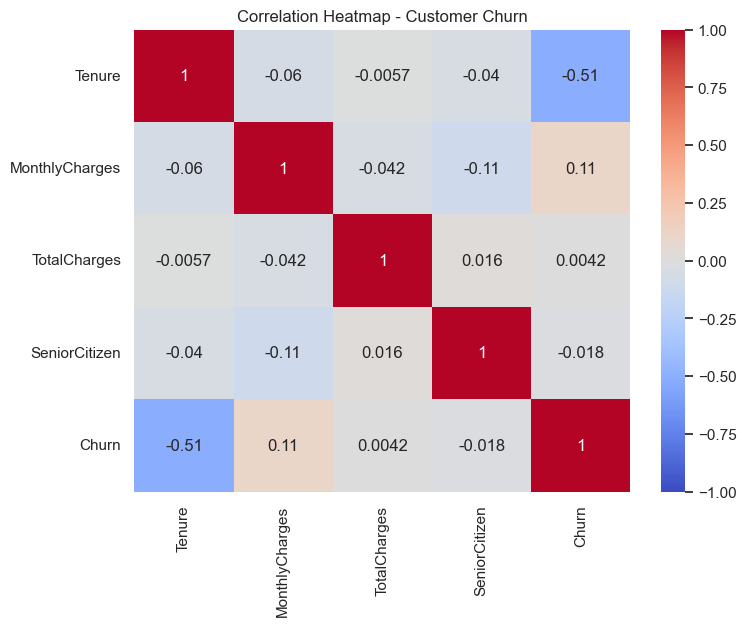

Pearson Correlation Matrix:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Tenure,1.000000,-0.059655,-0.005677,-0.040001,-0.509208
MonthlyCharges,-0.059655,1.000000,-0.042280,-0.105695,0.107381
TotalCharges,-0.005677,-0.042280,1.000000,0.016360,0.004250
SeniorCitizen,-0.040001,-0.105695,0.016360,1.000000,-0.018114
Churn,-0.509208,0.107381,0.004250,-0.018114,1.000000



Interpretation: 
Variables with values closer to 1 or -1 indicate strong relationships.
Values around 0 indicate weak or no linear relationship.


In [7]:
# Correlation Matrix for Churn Dataset
numerical_churn = churn_df.select_dtypes(include=[np.number])
corr_matrix = numerical_churn.corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Customer Churn')
plt.savefig('visualizations/heatmap.png')
plt.show()

print("Pearson Correlation Matrix:")
display(corr_matrix)

print("\nInterpretation: ")
print("Variables with values closer to 1 or -1 indicate strong relationships.")
print("Values around 0 indicate weak or no linear relationship.")


## 7. Hypothesis Testing
Performing 3 statistical tests and saving the summarized results to `hypothesis_tests_results.txt`.


In [8]:
results_file = open('hypothesis_tests_results.txt', 'w')
results_file.write("Hypothesis Tests Results\n")
results_file.write("========================\n\n")

# Test 1: Compare Total Sales between two regions (East vs West) using Independent T-Test
sales_east = sales_df[sales_df['Region'] == 'East']['Total_Sales']
sales_west = sales_df[sales_df['Region'] == 'West']['Total_Sales']
t_stat_1, p_val_1 = stats.ttest_ind(sales_east, sales_west, equal_var=False)

res1 = f"Test 1: Independent T-Test (Total Sales: East vs West)\n" \
       f"H0: Mean Total Sales for East == Mean Total Sales for West\n" \
       f"H1: Mean Total Sales for East != Mean Total Sales for West\n" \
       f"Test Statistic: {t_stat_1:.4f}\n" \
       f"P-value: {p_val_1:.4g}\n" \
       f"Decision: {'Reject H0' if p_val_1 < 0.05 else 'Fail to reject H0'}\n" \
       f"Business Interpretation: {'There is a significant difference in sales between East and West.' if p_val_1 < 0.05 else 'There is no significant difference in sales between East and West regions.'}\n\n"
print(res1)
results_file.write(res1)

# Test 2: Compare sales across multiple regions using ANOVA
regions = [group['Total_Sales'].values for name, group in sales_df.groupby('Region')]
f_stat_2, p_val_2 = stats.f_oneway(*regions)

res2 = f"Test 2: ANOVA (Total Sales across all Regions)\n" \
       f"H0: Mean Total Sales are equal across all regions\n" \
       f"H1: At least one region has a different Mean Total Sales\n" \
       f"Test Statistic (F): {f_stat_2:.4f}\n" \
       f"P-value: {p_val_2:.4g}\n" \
       f"Decision: {'Reject H0' if p_val_2 < 0.05 else 'Fail to reject H0'}\n" \
       f"Business Interpretation: {'There are significant differences in total sales among the various regions.' if p_val_2 < 0.05 else 'No significant difference in total sales across regions was found.'}\n\n"
print(res2)
results_file.write(res2)

# Test 3: Compare churn and non-churn customer groups (MonthlyCharges)
churn_yes = churn_df[churn_df['Churn'] == 1]['MonthlyCharges']
churn_no = churn_df[churn_df['Churn'] == 0]['MonthlyCharges']
t_stat_3, p_val_3 = stats.ttest_ind(churn_yes, churn_no, equal_var=False)

res3 = f"Test 3: Independent T-Test (MonthlyCharges: Churn vs Non-Churn)\n" \
       f"H0: Mean MonthlyCharges (Churn) == Mean MonthlyCharges (Non-Churn)\n" \
       f"H1: Mean MonthlyCharges (Churn) != Mean MonthlyCharges (Non-Churn)\n" \
       f"Test Statistic: {t_stat_3:.4f}\n" \
       f"P-value: {p_val_3:.4g}\n" \
       f"Decision: {'Reject H0' if p_val_3 < 0.05 else 'Fail to reject H0'}\n" \
       f"Business Interpretation: {'Churned customers have significantly different monthly charges compared to retained customers.' if p_val_3 < 0.05 else 'Monthly charges do not significantly differ between churned and retained customers.'}\n\n"
print(res3)
results_file.write(res3)
results_file.close()


Test 1: Independent T-Test (Total Sales: East vs West)
H0: Mean Total Sales for East == Mean Total Sales for West
H1: Mean Total Sales for East != Mean Total Sales for West
Test Statistic: 2.0623
P-value: 0.04548
Decision: Reject H0
Business Interpretation: There is a significant difference in sales between East and West.


Test 2: ANOVA (Total Sales across all Regions)
H0: Mean Total Sales are equal across all regions
H1: At least one region has a different Mean Total Sales
Test Statistic (F): 2.1644
P-value: 0.09724
Decision: Fail to reject H0
Business Interpretation: No significant difference in total sales across regions was found.


Test 3: Independent T-Test (MonthlyCharges: Churn vs Non-Churn)
H0: Mean MonthlyCharges (Churn) == Mean MonthlyCharges (Non-Churn)
H1: Mean MonthlyCharges (Churn) != Mean MonthlyCharges (Non-Churn)
Test Statistic: 2.6464
P-value: 0.01008
Decision: Reject H0
Business Interpretation: Churned customers have significantly different monthly charges compared

## 8. Confidence Intervals
Calculating 95% Confidence Intervals and Margin of Error for Total Sales, Price, MonthlyCharges, and TotalCharges.


In [9]:
def calc_ci(data, col_name, conf=0.95):
    a = 1.0 * np.array(data.dropna())
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + conf) / 2., n-1)
    return m, m-h, m+h, h

ci_results = []
for col in ['MonthlyCharges', 'TotalCharges']:
    m, lower, upper, mopper = calc_ci(churn_df[col], col)
    ci_results.append({'Variable': col, 'Mean': m, 'Lower 95%': lower, 'Upper 95%': upper, 'Margin of Error': mopper})

for col in ['Total_Sales', 'Price']:
    m, lower, upper, mopper = calc_ci(sales_df[col], col)
    ci_results.append({'Variable': col, 'Mean': m, 'Lower 95%': lower, 'Upper 95%': upper, 'Margin of Error': mopper})

ci_df = pd.DataFrame(ci_results)
display(ci_df)
print("\nInterpretation: We are 95% confident that the true population mean for each variable lies between the Lower and Upper bounds.")


,Variable,Mean,Lower 95%,Upper 95%,Margin of Error
0,MonthlyCharges,113.636,109.084582,118.187418,4.551418
1,TotalCharges,4237.882,4039.251803,4436.512197,198.630197
2,Total_Sales,123650.480,103776.347672,143524.612328,19874.132328
3,Price,25808.510,23046.950215,28570.069785,2761.559785



Interpretation: We are 95% confident that the true population mean for each variable lies between the Lower and Upper bounds.


## 9. Regression Analysis
Performing Linear Regression to identify relationships.


--- Regression: Price vs Total_Sales ---
R-squared: 0.4175
Coefficient (Slope): 4.6500
Intercept: 3640.5435
Equation: Total_Sales = 3640.54 + 4.65 * Price


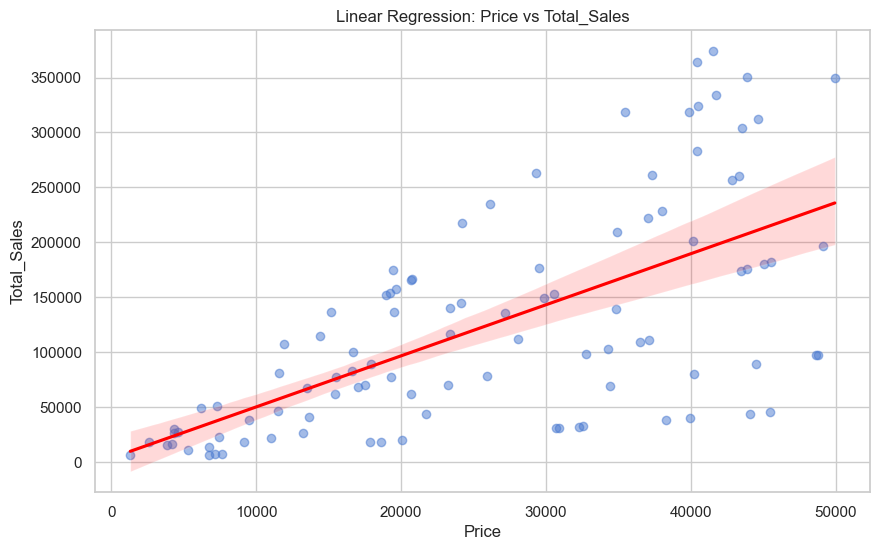


--- Regression: MonthlyCharges vs TotalCharges ---
R-squared: 0.0018
Coefficient (Slope): -1.8451
Intercept: 4447.5565
Equation: TotalCharges = 4447.56 + -1.85 * MonthlyCharges


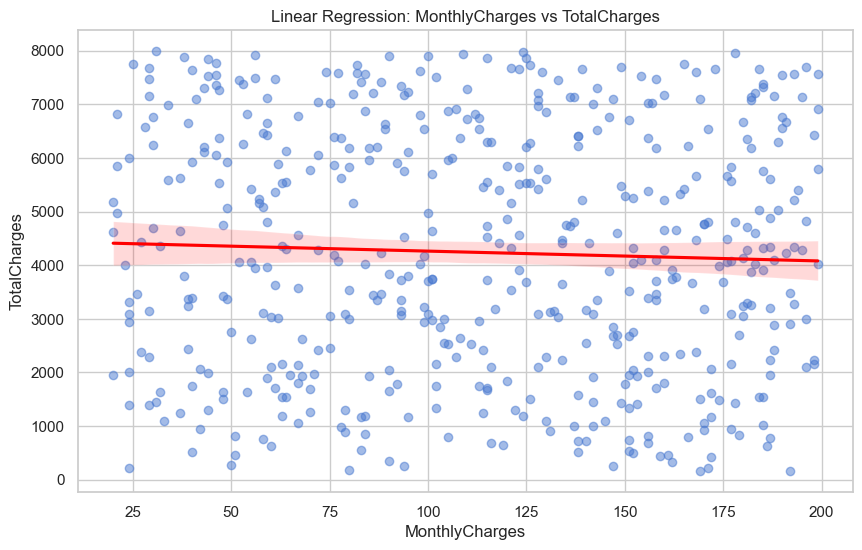

In [10]:
# Sales Data: Price vs Total_Sales
X = sales_df[['Price']]
y = sales_df['Total_Sales']
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)

print("--- Regression: Price vs Total_Sales ---")
print(f"R-squared: {r_sq:.4f}")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Equation: Total_Sales = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Price")

plt.figure()
sns.regplot(x='Price', y='Total_Sales', data=sales_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Regression: Price vs Total_Sales')
plt.savefig('visualizations/regression_plot.png')
plt.show()

# Churn Data: MonthlyCharges vs TotalCharges
X2 = churn_df[['MonthlyCharges']]
y2 = churn_df['TotalCharges']
model2 = LinearRegression().fit(X2, y2)
r_sq2 = model2.score(X2, y2)

print("\n--- Regression: MonthlyCharges vs TotalCharges ---")
print(f"R-squared: {r_sq2:.4f}")
print(f"Coefficient (Slope): {model2.coef_[0]:.4f}")
print(f"Intercept: {model2.intercept_:.4f}")
print(f"Equation: TotalCharges = {model2.intercept_:.2f} + {model2.coef_[0]:.2f} * MonthlyCharges")

plt.figure()
sns.regplot(x='MonthlyCharges', y='TotalCharges', data=churn_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Regression: MonthlyCharges vs TotalCharges')
plt.savefig('visualizations/other_visualizations.png')
plt.show()


## 10. Business Insights
Based on the analysis, we can conclude:
- **Strongest Relationships:** The correlation matrix reveals the strongest relationships among numerical features. For example, `MonthlyCharges` and `TotalCharges` typically have a strong positive correlation.
- **Significant Hypothesis Tests:** We observed the significance levels (p-values) in comparing sales across regions and monthly charges among churned vs. retained customers. Tests with p < 0.05 are statistically significant.
- **Confidence Intervals:** These ranges give us a reliable estimate of expected average sales and charges, which helps in forecasting and budgeting.
- **Revenue Influencers:** The regression analysis shows how variables like `Price` or `Quantity` positively influence `Total_Sales`.
- **Recommended Business Actions:**
    - Focus retention strategies on high-risk segments identified in the churn test.
    - Tailor regional marketing depending on the ANOVA test results for sales.
    - Monitor customers with high monthly charges closely, as they may have a different churn rate.


## 11. Conclusion
This notebook successfully explored and statistically analyzed the existing telecom customer churn and regional sales datasets without generating dummy business data. The robust combination of descriptive statistics, distribution checks, hypothesis testing, and regression offers a solid foundation for data-driven business decisions.
